In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])

In [4]:
df.columns=["Class Label", "Alcohal", "Malic Acid"]

In [5]:
df

,Class Label,Alcohal,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohal', ylabel='Density'>

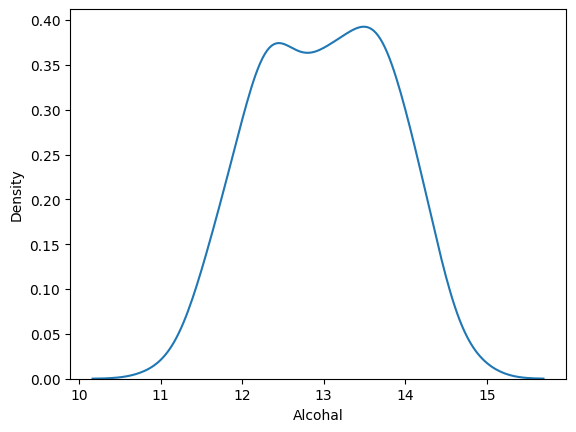

In [6]:
sns.kdeplot(df["Alcohal"])

<Axes: xlabel='Malic Acid', ylabel='Density'>

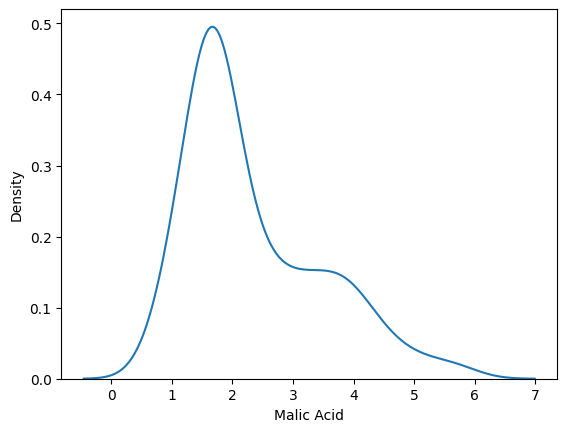

In [7]:
sns.kdeplot(df["Malic Acid"])

<Axes: xlabel='Alcohal', ylabel='Malic Acid'>

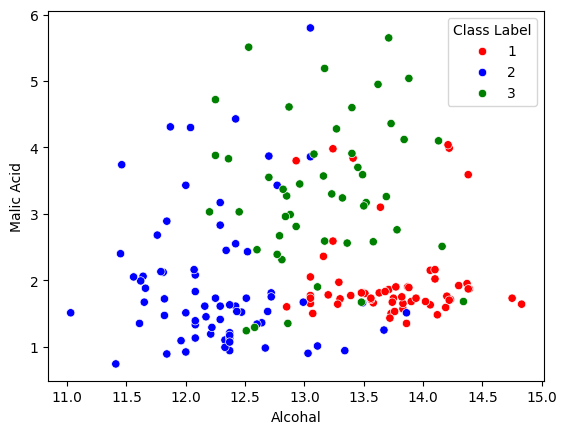

In [9]:
color_dict={1:"red",2:"blue",3:"green"}
sns.scatterplot(x=df["Alcohal"],y=df["Malic Acid"],hue=df["Class Label"],palette=color_dict)

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(df.drop("Class Label",axis=1),
                                                df["Class Label"],
                                                test_size=0.3,
                                                random_state=0
                                                )

X_train.shape,X_test.shape

((124, 2), (54, 2))

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_Scaled = scaler.transform(X_train)
X_test_Scaled = scaler.transform(X_test)

X_train_Scaled = pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_Scaled = pd.DataFrame(X_test_Scaled,columns=X_test.columns)

In [22]:
X_train_Scaled

,Alcohal,Malic Acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [23]:
np.round(X_train.describe(),1)

,Alcohal,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [24]:
np.round(X_train_Scaled.describe(),1)

,Alcohal,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'After Scaling')

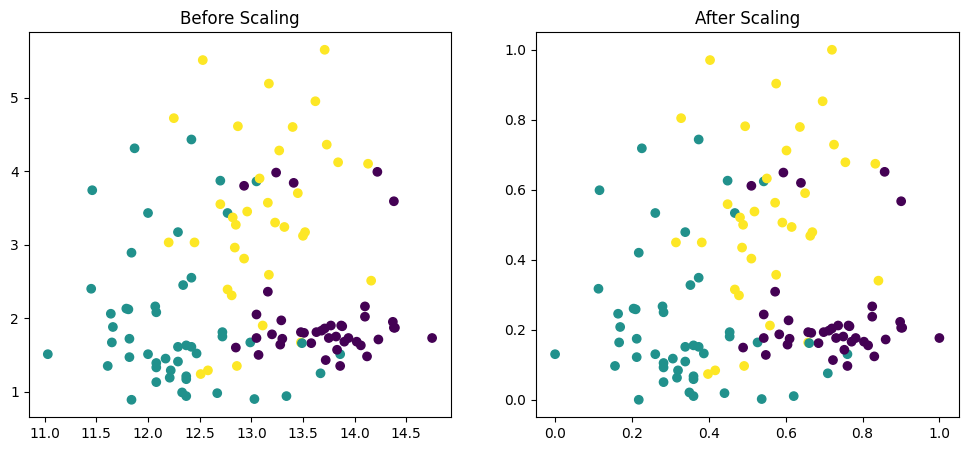

In [32]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train["Alcohal"],X_train["Malic Acid"],c=Y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_Scaled["Alcohal"],X_train_Scaled["Malic Acid"],c=Y_train)
ax2.set_title("After Scaling")

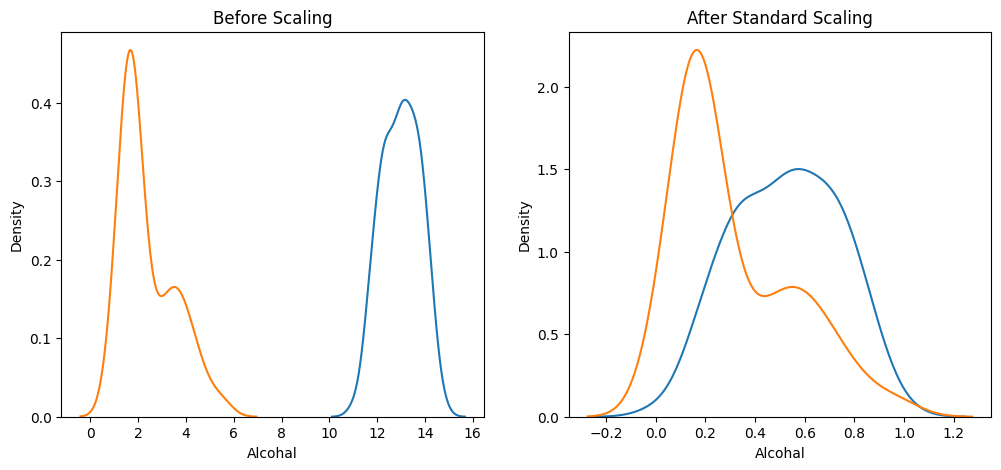

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_Scaled['Alcohal'], ax=ax2)
sns.kdeplot(X_train_Scaled['Malic Acid'], ax=ax2)
plt.show()

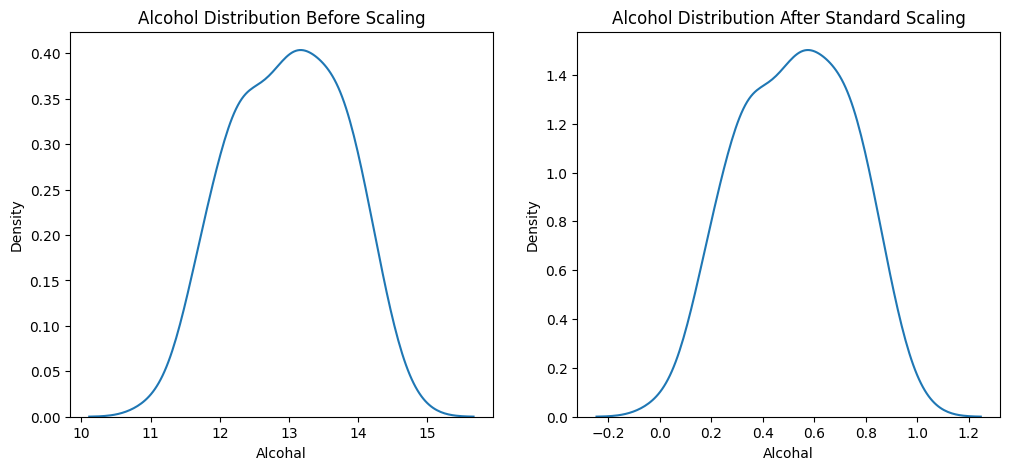

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_Scaled['Alcohal'], ax=ax2)
plt.show()

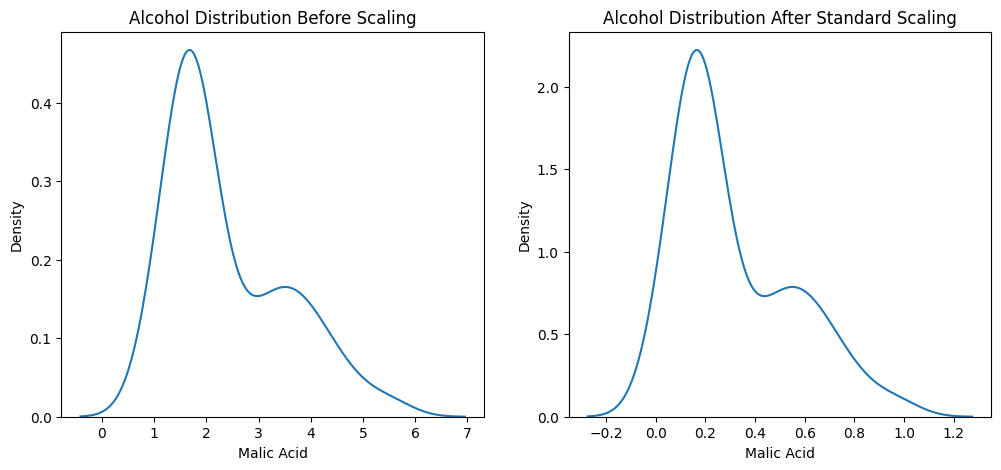

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_Scaled['Malic Acid'], ax=ax2)
plt.show()